In [1]:
#import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import pearsonr
import geopandas as gpd
from shapely.geometry import Point
from sklearn.neighbors import BallTree


In [2]:
# use forward slashes (or raw strings) to avoid backslash escape issues on Windows paths
df_prec = pd.read_csv('../../ExtractedDatasets/ClimateFeatures/prec_2020_2024.csv')
df_tmax = pd.read_csv('../../ExtractedDatasets/ClimateFeatures/tmax_2020_2024.csv')
df_tmin = pd.read_csv('../../ExtractedDatasets/ClimateFeatures/tmin_2020_2024.csv')

In [3]:
#Data shapes
print("Precipitation Data Shape:", df_prec.shape)
print("Max Temperature Data Shape:", df_tmax.shape)
print("Min Temperature Data Shape:", df_tmin.shape)

Precipitation Data Shape: (1399320, 4)
Max Temperature Data Shape: (1399320, 4)
Min Temperature Data Shape: (1399320, 4)


In [4]:
#Data memory usage
print("Precipitation Data Memory Usage:", df_prec.memory_usage(deep=True).sum() / (1024 ** 2), "MB")
print("Max Temperature Data Memory Usage:", df_tmax.memory_usage(deep=True).sum() / (1024 ** 2), "MB")
print("Min Temperature Data Memory Usage:", df_tmin.memory_usage(deep=True).sum() / (1024 ** 2), "MB")

Precipitation Data Memory Usage: 42.703983306884766 MB
Max Temperature Data Memory Usage: 42.703983306884766 MB
Min Temperature Data Memory Usage: 42.703983306884766 MB


In [5]:
# decribing datasets
print("Precipitation Data Description:")
print(df_prec.describe())
print("\nTmax Data Description:")
print(df_tmax.describe())
print("\nTmin Data Description:")
print(df_tmin.describe())

Precipitation Data Description:
            cell_id          year         month       prec_mm
count  1.399320e+06  1.399320e+06  1.399320e+06  1.383840e+06
mean   1.166050e+04  2.022000e+03  6.500000e+00  5.592143e+00
std    6.732484e+03  1.414214e+00  3.452054e+00  1.364259e+01
min    0.000000e+00  2.020000e+03  1.000000e+00  0.000000e+00
25%    5.830000e+03  2.021000e+03  3.750000e+00  7.250000e-01
50%    1.166050e+04  2.022000e+03  6.500000e+00  1.575000e+00
75%    1.749100e+04  2.023000e+03  9.250000e+00  4.075000e+00
max    2.332100e+04  2.024000e+03  1.200000e+01  3.686750e+02

Tmax Data Description:
            cell_id          year         month        tmax_c
count  1.399320e+06  1.399320e+06  1.399320e+06  1.383840e+06
mean   1.166050e+04  2.022000e+03  6.500000e+00  3.108703e+01
std    6.732484e+03  1.414214e+00  3.452054e+00  8.805030e+00
min    0.000000e+00  2.020000e+03  1.000000e+00  4.500000e+00
25%    5.830000e+03  2.021000e+03  3.750000e+00  2.400000e+01
50%    1.16605

In [6]:
# functionto calculate % of missing values
def missing_percentage(df):
    missing_count = df.isnull().sum().sum()
    total_count = df.size
    return (missing_count / total_count) * 100

In [7]:
print("Precipitation Data Missing Percentage: {:.2f}%".format(missing_percentage(df_prec)))
print("Max Temperature Data Missing Percentage: {:.2f}%".format(missing_percentage(df_tmax)))
print("Min Temperature Data Missing Percentage: {:.2f}%".format(missing_percentage(df_tmin)))

Precipitation Data Missing Percentage: 0.28%
Max Temperature Data Missing Percentage: 0.28%
Min Temperature Data Missing Percentage: 0.28%


In [8]:
#display rows where there are missing values
df_missing_prec = df_prec[df_prec.isnull().any(axis=1)]

df_missing_tmax = df_tmax[df_tmax.isnull().any(axis=1)]

df_missing_tmin = df_tmin[df_tmin.isnull().any(axis=1)]

In [9]:
#display the missing value rows
print("Missing Precipitation Data Rows:")
print(df_missing_prec)

Missing Precipitation Data Rows:
         cell_id  year  month  prec_mm
16            16  2020      1      NaN
33            33  2020      1      NaN
51            51  2020      1      NaN
71            71  2020      1      NaN
113          113  2020      1      NaN
...          ...   ...    ...      ...
1399258    23260  2024     12      NaN
1399259    23261  2024     12      NaN
1399279    23281  2024     12      NaN
1399317    23319  2024     12      NaN
1399319    23321  2024     12      NaN

[15480 rows x 4 columns]


In [10]:
#check what columns have missing values
print("Columns with missing values in Precipitation Data:")
print(df_missing_prec.columns[df_missing_prec.isnull().any()].tolist())
print("\nColumns with missing values in Max Temperature Data:")
print(df_missing_tmax.columns[df_missing_tmax.isnull().any()].tolist())
print("\nColumns with missing values in Min Temperature Data:")
print(df_missing_tmin.columns[df_missing_tmin.isnull().any()].tolist())

Columns with missing values in Precipitation Data:
['prec_mm']

Columns with missing values in Max Temperature Data:
['tmax_c']

Columns with missing values in Min Temperature Data:
['tmin_c']


In [11]:
# compare cell_id across the three missing-dataframes and show rows where they differ
cols = ['cell_id']
df_cmp = pd.concat([df_missing_prec[cols], df_missing_tmax[cols], df_missing_tmin[cols]], axis=1, keys=['prec','tmax','tmin'])
df_cmp.columns = ['prec_cell_id', 'tmax_cell_id', 'tmin_cell_id']

# rows where not all three cell_id values are equal
equal_mask = (df_cmp['prec_cell_id'] == df_cmp['tmax_cell_id']) & (df_cmp['prec_cell_id'] == df_cmp['tmin_cell_id'])
diff_idx = df_cmp.index[~equal_mask]

if len(diff_idx) == 0:
    print("All cell_id values are identical across df_missing_prec, df_missing_tmax and df_missing_tmin.")
else:
    print(f"{len(diff_idx)} rows have differing cell_id values. Showing full rows from each dataframe for those indices:")
    df_diff_full = pd.concat([
        df_missing_prec.loc[diff_idx].add_prefix('prec_'),
        df_missing_tmax.loc[diff_idx].add_prefix('tmax_'),
        df_missing_tmin.loc[diff_idx].add_prefix('tmin_')
    ], axis=1)
    df_diff_full

All cell_id values are identical across df_missing_prec, df_missing_tmax and df_missing_tmin.


In [12]:
# # combine indices of rows that had missing values and drop them from the original dataframes
# missing_idx = df_missing_prec.index.union(df_missing_tmax.index).union(df_missing_tmin.index)
# print(f"Dropping {len(missing_idx)} rows with missing values from each dataframe.")

# df_prec.drop(index=missing_idx, inplace=True)
# df_tmax.drop(index=missing_idx, inplace=True)
# df_tmin.drop(index=missing_idx, inplace=True)

# # quick verification
# print("Remaining missing in prec_mm:", df_prec['prec_mm'].isnull().sum())
# print("Remaining missing in tmax_c:", df_tmax['tmax_c'].isnull().sum())
# print("Remaining missing in tmin_c:", df_tmin['tmin_c'].isnull().sum())

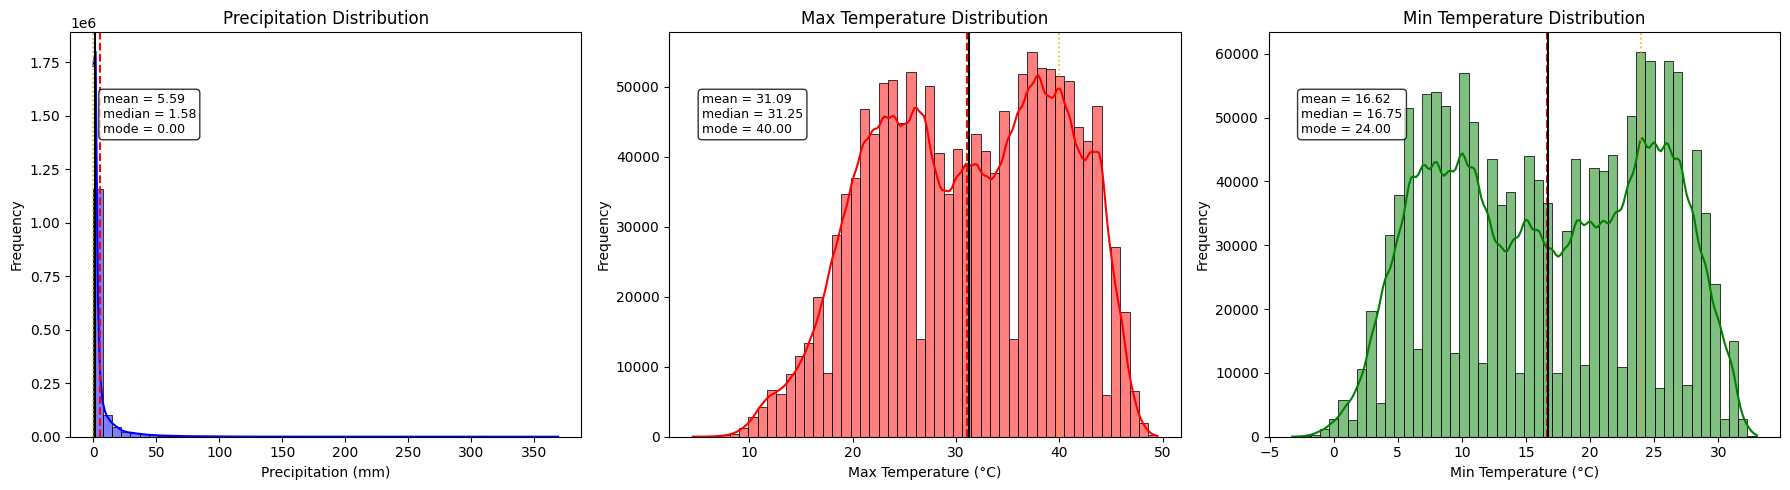

In [13]:
# Create output directory for figures
output_dir = '../../Rapport_TP/images/Climate/'
os.makedirs(output_dir, exist_ok=True)

# visualization with histograms + mean/median/mode annotations
plt.figure(figsize=(18, 5))

series_info = [
    (df_prec['prec_mm'], 'Precipitation (mm)', 'Precipitation Distribution', 'blue'),
    (df_tmax['tmax_c'], 'Max Temperature (°C)', 'Max Temperature Distribution', 'red'),
    (df_tmin['tmin_c'], 'Min Temperature (°C)', 'Min Temperature Distribution', 'green'),
]

for i, (s, xlabel, title, color) in enumerate(series_info, 1):
    ax = plt.subplot(1, 3, i)
    sns.histplot(s, bins=50, kde=True, color=color, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Frequency')

    # statistics
    mean_v = s.mean()
    med_v = s.median()
    modes = s.mode().tolist()
    if len(modes) == 0:
        mode_str = "NaN"
    else:
        # show up to first 3 mode values
        mode_str = ", ".join(f"{m:.2f}" for m in modes[:3])

    # vertical lines
    ax.axvline(mean_v, color='red', linestyle='--', linewidth=1.5, label=f"mean: {mean_v:.2f}")
    ax.axvline(med_v, color='black', linestyle='-', linewidth=1.5, label=f"median: {med_v:.2f}")
    # draw mode lines (may be multiple)
    for j, mv in enumerate(modes[:3]):
        ax.axvline(mv, color='orange', linestyle=':', linewidth=1.2, alpha=0.9 if j==0 else 0.6)

    # annotation text in upper left
    ylim = ax.get_ylim()
    xpos = 0.02 * (s.max() - s.min()) + s.min()
    ypos = ylim[1] * 0.85
    ax.text(xpos, ypos, f"mean = {mean_v:.2f}\nmedian = {med_v:.2f}\nmode = {mode_str}",
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8),
            fontsize=9, verticalalignment='top')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'climate_histograms_raw.png'), dpi=300, bbox_inches='tight')
plt.show()

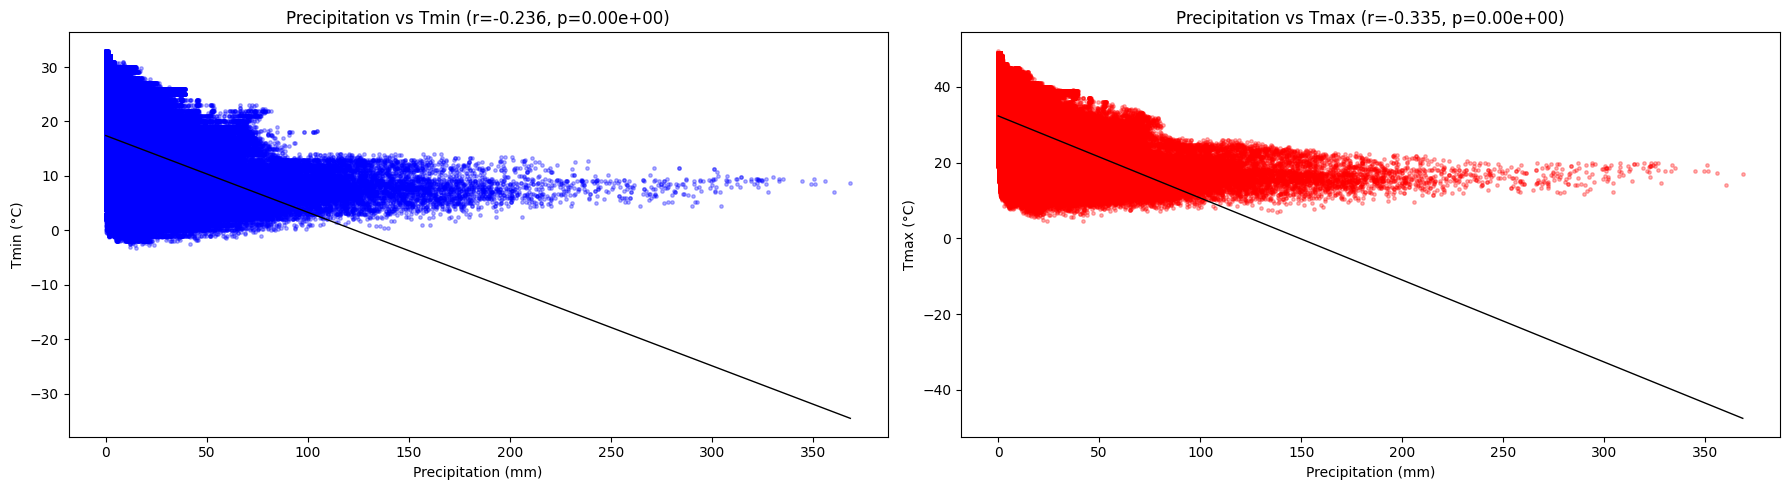

Prec vs Tmin: r = -0.2363, p = 0.0000e+00
Prec vs Tmax: r = -0.3353, p = 0.0000e+00


In [14]:
# create a fresh figure/axes to ensure plots render (don't rely on previously created axes)
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# (re)merge and drop NaNs to be safe
merge_tmin = pd.merge(df_prec[['cell_id','year','month','prec_mm']],
                      df_tmin[['cell_id','year','month','tmin_c']],
                      on=['cell_id','year','month']).dropna(subset=['prec_mm','tmin_c'])
merge_tmax = pd.merge(df_prec[['cell_id','year','month','prec_mm']],
                      df_tmax[['cell_id','year','month','tmax_c']],
                      on=['cell_id','year','month']).dropna(subset=['prec_mm','tmax_c'])

# compute Pearson correlations
r_tmin, p_tmin = pearsonr(merge_tmin['prec_mm'], merge_tmin['tmin_c'])
r_tmax, p_tmax = pearsonr(merge_tmax['prec_mm'], merge_tmax['tmax_c'])

# scatter prec vs tmin
axes[0].scatter(merge_tmin['prec_mm'], merge_tmin['tmin_c'], s=6, alpha=0.3, color='blue', marker='o')
axes[0].set_title(f'Precipitation vs Tmin (r={r_tmin:.3f}, p={p_tmin:.2e})')
axes[0].set_xlabel('Precipitation (mm)')
axes[0].set_ylabel('Tmin (°C)')
m, b = np.polyfit(merge_tmin['prec_mm'], merge_tmin['tmin_c'], 1)
xs = np.linspace(merge_tmin['prec_mm'].min(), merge_tmin['prec_mm'].max(), 100)
axes[0].plot(xs, m*xs + b, color='black', lw=1)

# scatter prec vs tmax
axes[1].scatter(merge_tmax['prec_mm'], merge_tmax['tmax_c'], s=6, alpha=0.3, color='red', marker='o')
axes[1].set_title(f'Precipitation vs Tmax (r={r_tmax:.3f}, p={p_tmax:.2e})')
axes[1].set_xlabel('Precipitation (mm)')
axes[1].set_ylabel('Tmax (°C)')
m2, b2 = np.polyfit(merge_tmax['prec_mm'], merge_tmax['tmax_c'], 1)
xs2 = np.linspace(merge_tmax['prec_mm'].min(), merge_tmax['prec_mm'].max(), 100)
axes[1].plot(xs2, m2*xs2 + b2, color='black', lw=1)


plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'prec_vs_temperature_scatter.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f'Prec vs Tmin: r = {r_tmin:.4f}, p = {p_tmin:.4e}')
print(f'Prec vs Tmax: r = {r_tmax:.4f}, p = {p_tmax:.4e}')

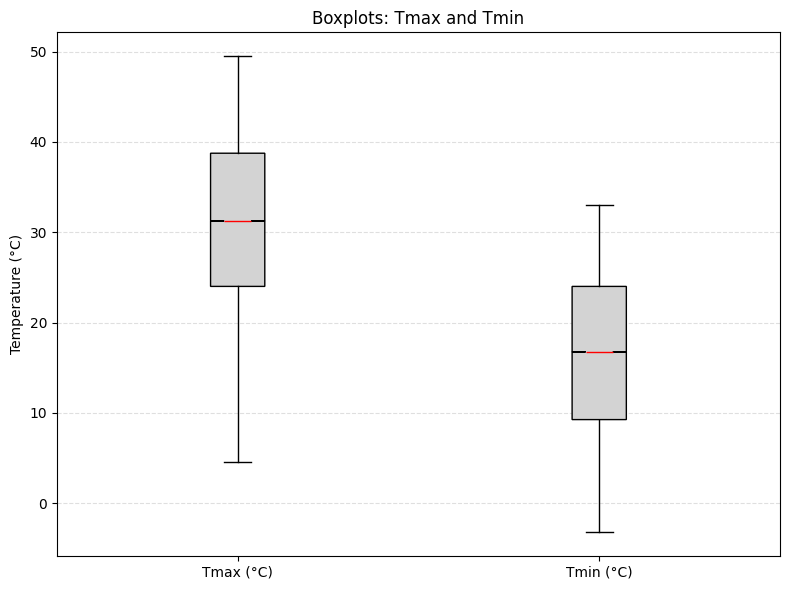

In [15]:
plt.figure(figsize=(8,6))
data = [df_tmax['tmax_c'].dropna(), df_tmin['tmin_c'].dropna()]
plt.boxplot(data, notch=True, patch_artist=True,
            boxprops=dict(facecolor='lightgray', color='black'),
            medianprops=dict(color='red'),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            flierprops=dict(marker='.', markerfacecolor='gray', markersize=3, alpha=0.5))
plt.xticks([1, 2], ['Tmax (°C)', 'Tmin (°C)'])
plt.title('Boxplots: Tmax and Tmin')
plt.ylabel('Temperature (°C)')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'temperature_boxplots.png'), dpi=300, bbox_inches='tight')
plt.show()

In [16]:
# select month an year of df_missing_prec
df_missing_prec[['year', 'month']]


,year,month
16,2020,1
33,2020,1
51,2020,1
71,2020,1
113,2020,1
...,...,...
1399258,2024,12
1399259,2024,12
1399279,2024,12
1399317,2024,12


# Spatial Visualization with Geopandas

In [17]:
# Load the spatial grid (created during data extraction)
GRID_PATH = r"../../ExtractedDatasets/ClimateFeatures/grid_0p1.gpkg"
grid = gpd.read_file(GRID_PATH, layer="grid")

print(f"Grid shape: {grid.shape}")
print(f"Grid CRS: {grid.crs}")
print(f"Grid columns: {grid.columns.tolist()}")
grid.head()

Grid shape: (23322, 2)
Grid CRS: EPSG:4326
Grid columns: ['cell_id', 'geometry']


,cell_id,geometry
0,0,"MULTIPOLYGON (((-8.56891 27.26815, -8.56891 27..."
1,1,"MULTIPOLYGON (((-8.56891 27.36815, -8.56891 27..."
2,2,"MULTIPOLYGON (((-8.56891 27.46815, -8.56891 27..."
3,3,"MULTIPOLYGON (((-8.56891 27.56815, -8.56891 27..."
4,4,"MULTIPOLYGON (((-8.56891 27.66815, -8.56891 27..."


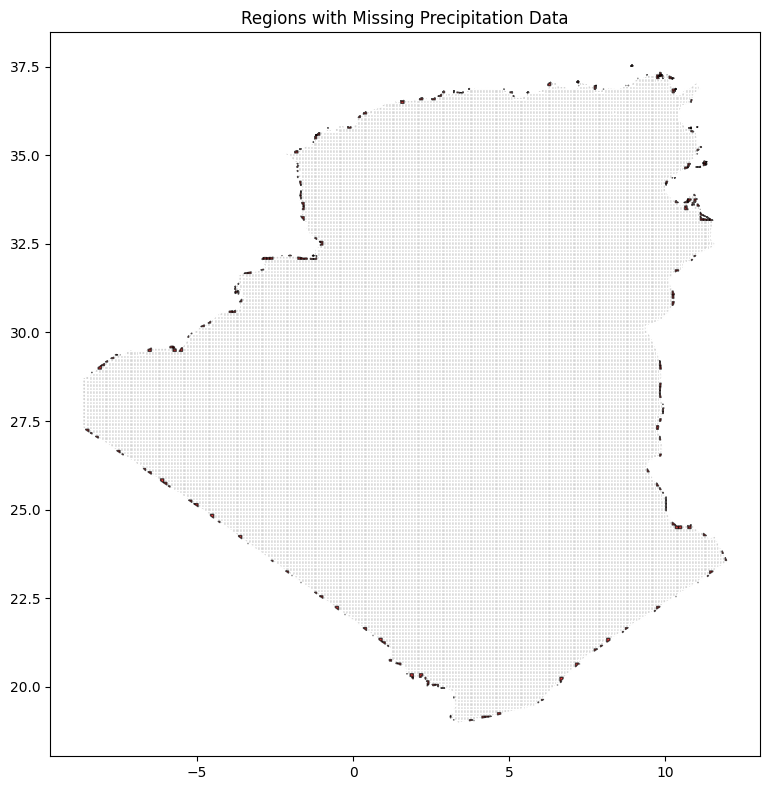

In [18]:
# map regions where precipitation data is missing df_missing_prec
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
base = grid.plot(ax=ax, color='lightgray', edgecolor='white')
missing_cells = df_missing_prec['cell_id'].unique()
grid_missing = grid[grid['cell_id'].isin(missing_cells)]
grid_missing.plot(ax=base, color='red', edgecolor='black', alpha=0.7)
plt.title('Regions with Missing Precipitation Data')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'missing_precipitation_spatial.png'), dpi=300, bbox_inches='tight')
plt.show()

In [19]:
#add centroids lat/lon to grid for spatial joins
grid['centroid'] = grid.geometry.centroid
grid['lon'] = grid['centroid'].x
grid['lat'] = grid['centroid'].y

# merge precipitation data with grid based on cell_id
df_prec_spatial = grid.merge(df_prec, on='cell_id', how='left')
df_prec_spatial.drop(columns=['centroid'], inplace=True)
df_tmax_spatial = grid.merge(df_tmax, on='cell_id', how='left')
df_tmax_spatial.drop(columns=['centroid'], inplace=True)
df_tmin_spatial = grid.merge(df_tmin, on='cell_id', how='left')
df_tmin_spatial.drop(columns=['centroid'], inplace=True)

C:\Users\E15\AppData\Local\Temp\ipykernel_1092\1785687143.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  grid['centroid'] = grid.geometry.centroid


# Spatio-Temporal KNN Imputation for Missing Climate Data

In [20]:
print("Data merged with spatial coordinates:")
print(f"Precipitation: {df_prec_spatial.shape}")
print(f"Tmax: {df_tmax_spatial.shape}")
print(f"Tmin: {df_tmin_spatial.shape}")
print("\nSample with coordinates:")
df_prec_spatial.head()

Data merged with spatial coordinates:
Precipitation: (1399320, 7)
Tmax: (1399320, 7)
Tmin: (1399320, 7)

Sample with coordinates:


,cell_id,geometry,lon,lat,year,month,prec_mm
0,0,"MULTIPOLYGON (((-8.56891 27.26815, -8.56891 27...",-8.575374,27.264357,2020,1,2.000
1,0,"MULTIPOLYGON (((-8.56891 27.26815, -8.56891 27...",-8.575374,27.264357,2020,2,0.500
2,0,"MULTIPOLYGON (((-8.56891 27.26815, -8.56891 27...",-8.575374,27.264357,2020,3,0.575
3,0,"MULTIPOLYGON (((-8.56891 27.26815, -8.56891 27...",-8.575374,27.264357,2020,4,0.600
4,0,"MULTIPOLYGON (((-8.56891 27.26815, -8.56891 27...",-8.575374,27.264357,2020,5,0.000


In [21]:
def knn_spatiotemporal_impute(
    df,
    var_col,
    k=8,
    search_mult=10,
    use_median=True,
    verbose=True
):
    """
    Impute missing values using spatio-temporal KNN + controlled fallbacks.
    
    df must have: year, month, lat, lon, var_col.
    """
    df_imputed = df.copy()

    # Keep original index
    original_index = df_imputed.index.copy()
    df_imputed = df_imputed.reset_index(drop=True)

    # Build spatial KNN (Haversine)
    coords_rad = np.radians(df_imputed[["lat", "lon"]].values)
    tree = BallTree(coords_rad, metric="haversine")

    # Indices with NaNs
    nan_mask = df_imputed[var_col].isna()
    nan_idx = df_imputed.index[nan_mask].tolist()

    if len(nan_idx) == 0:
        if verbose:
            print(f"No missing values found in '{var_col}'")
        df_imputed.index = original_index
        return df_imputed

    if verbose:
        print(f"Imputing {len(nan_idx)} missing values in '{var_col}'...")

    imputed_count = 0
    failed_count = 0

    for i in nan_idx:
        lat_i = df_imputed.at[i, "lat"]
        lon_i = df_imputed.at[i, "lon"]
        year_i = df_imputed.at[i, "year"]
        month_i = df_imputed.at[i, "month"]

        # Spatial neighborhood (wider, we filter later)
        n_search = min(len(df_imputed), k * search_mult)
        dist, idxs = tree.query(
            np.radians([[lat_i, lon_i]]),
            k=n_search
        )

        neighbor_indices = idxs[0]
        neigh = df_imputed.iloc[neighbor_indices].copy()

        # Exclude self
        neigh = neigh[neigh.index != i]

        # Preference order:
        candidates = [
            (neigh["year"] == year_i) & (neigh["month"] == month_i),  # same year & month
            (neigh["month"] == month_i),                              # same month, any year
            (neigh["year"] == year_i),                                # same year, any month
        ]

        fill_value = None
        for mask in candidates:
            valid = neigh[mask & (~neigh[var_col].isna())]
            if len(valid) >= max(3, k // 2):
                valid = valid.iloc[:k]
                fill_value = valid[var_col].median() if use_median else valid[var_col].mean()
                break

        # Last resort (still KNN-based): ignore time, just nearest non-NaN
        if fill_value is None:
            valid = neigh[~neigh[var_col].isna()].iloc[:k]
            if len(valid) > 0:
                fill_value = valid[var_col].median() if use_median else valid[var_col].mean()

        if fill_value is not None:
            df_imputed.at[i, var_col] = fill_value
            imputed_count += 1
        else:
            failed_count += 1

    if verbose:
        print(f"Primary KNN imputation done for '{var_col}'.")
        print(f"  Successfully imputed: {imputed_count}/{len(nan_idx)}")
        print(f"  Failed (need fallback): {failed_count}/{len(nan_idx)}")
        print(f"  Remaining NaNs after KNN: {df_imputed[var_col].isna().sum()}")

    # ---------- Fallbacks (only for remaining NaNs) ----------

    # 1) Monthly climatology (same month, all years, all space)
    rem_mask = df_imputed[var_col].isna()
    if rem_mask.any():
        if verbose:
            print(f"Applying monthly climatology fallback for '{var_col}'...")
        if use_median:
            month_stats = df_imputed.groupby("month")[var_col].median()
        else:
            month_stats = df_imputed.groupby("month")[var_col].mean(skipna=True)

        df_imputed.loc[rem_mask, var_col] = df_imputed.loc[rem_mask, "month"].map(month_stats)

    # 2) Global fill (only if still something is broken)
    rem_mask = df_imputed[var_col].isna()
    if rem_mask.any():
        if verbose:
            print(f"Applying global fallback for '{var_col}'...")
        global_fill = df_imputed[var_col].median() if use_median else df_imputed[var_col].mean()
        df_imputed.loc[rem_mask, var_col] = global_fill

    if verbose:
        print(f"Final remaining NaNs in '{var_col}': {df_imputed[var_col].isna().sum()}")

    # Restore original index
    df_imputed.index = original_index
    return df_imputed


In [22]:
print("="*80)
print("IMPUTING CLIMATE VARIABLES (KNN + FALLBACK)")
print("="*80)

# Precip
df_prec_imputed = knn_spatiotemporal_impute(
    df_prec_spatial,
    var_col='prec_mm',
    k=8,
    search_mult=10,
    use_median=True,
    verbose=True
)

# Tmax
df_tmax_imputed = knn_spatiotemporal_impute(
    df_tmax_spatial,
    var_col='tmax_c',
    k=8,
    search_mult=10,
    use_median=True,
    verbose=True
)

# Tmin
df_tmin_imputed = knn_spatiotemporal_impute(
    df_tmin_spatial,
    var_col='tmin_c',
    k=8,
    search_mult=10,
    use_median=True,
    verbose=True
)

print("="*80)
print("FINAL SUMMARY")
print("="*80)
print("Precip missing:", df_prec_imputed['prec_mm'].isna().sum())
print("Tmax   missing:", df_tmax_imputed['tmax_c'].isna().sum())
print("Tmin   missing:", df_tmin_imputed['tmin_c'].isna().sum())
print("="*80)


IMPUTING CLIMATE VARIABLES (KNN + FALLBACK)
Imputing 15480 missing values in 'prec_mm'...
Primary KNN imputation done for 'prec_mm'.
  Successfully imputed: 11940/15480
  Failed (need fallback): 3540/15480
  Remaining NaNs after KNN: 3540
Applying monthly climatology fallback for 'prec_mm'...
Final remaining NaNs in 'prec_mm': 0
Imputing 15480 missing values in 'tmax_c'...
Primary KNN imputation done for 'tmax_c'.
  Successfully imputed: 11940/15480
  Failed (need fallback): 3540/15480
  Remaining NaNs after KNN: 3540
Applying monthly climatology fallback for 'tmax_c'...
Final remaining NaNs in 'tmax_c': 0
Imputing 15480 missing values in 'tmin_c'...
Primary KNN imputation done for 'tmin_c'.
  Successfully imputed: 11940/15480
  Failed (need fallback): 3540/15480
  Remaining NaNs after KNN: 3540
Applying monthly climatology fallback for 'tmin_c'...
Final remaining NaNs in 'tmin_c': 0
FINAL SUMMARY
Precip missing: 0
Tmax   missing: 0
Tmin   missing: 0


# Climate Variable Visualizations

This section provides comprehensive visual exploration of the imputed climate variables:
- Precipitation (`prec_mm`)
- Maximum temperature (`tmax_c`)
- Minimum temperature (`tmin_c`)

For each variable we include:
1. Histogram with KDE + summary statistics (mean, median, mode)
2. Quantile-Quantile (QQ) plot vs normal distribution to assess tail behavior
3. Scatter plot of value vs latitude (to inspect latitudinal gradients)
4. Scatter plot of value vs longitude (to inspect longitudinal gradients)

Additionally, we produce spatial heatmaps:
- Mean value across all months (2020-2024)
- Sample month (January 2020) for local patterns

Subplots are used for side-by-side comparison. All figures are sized for readability.

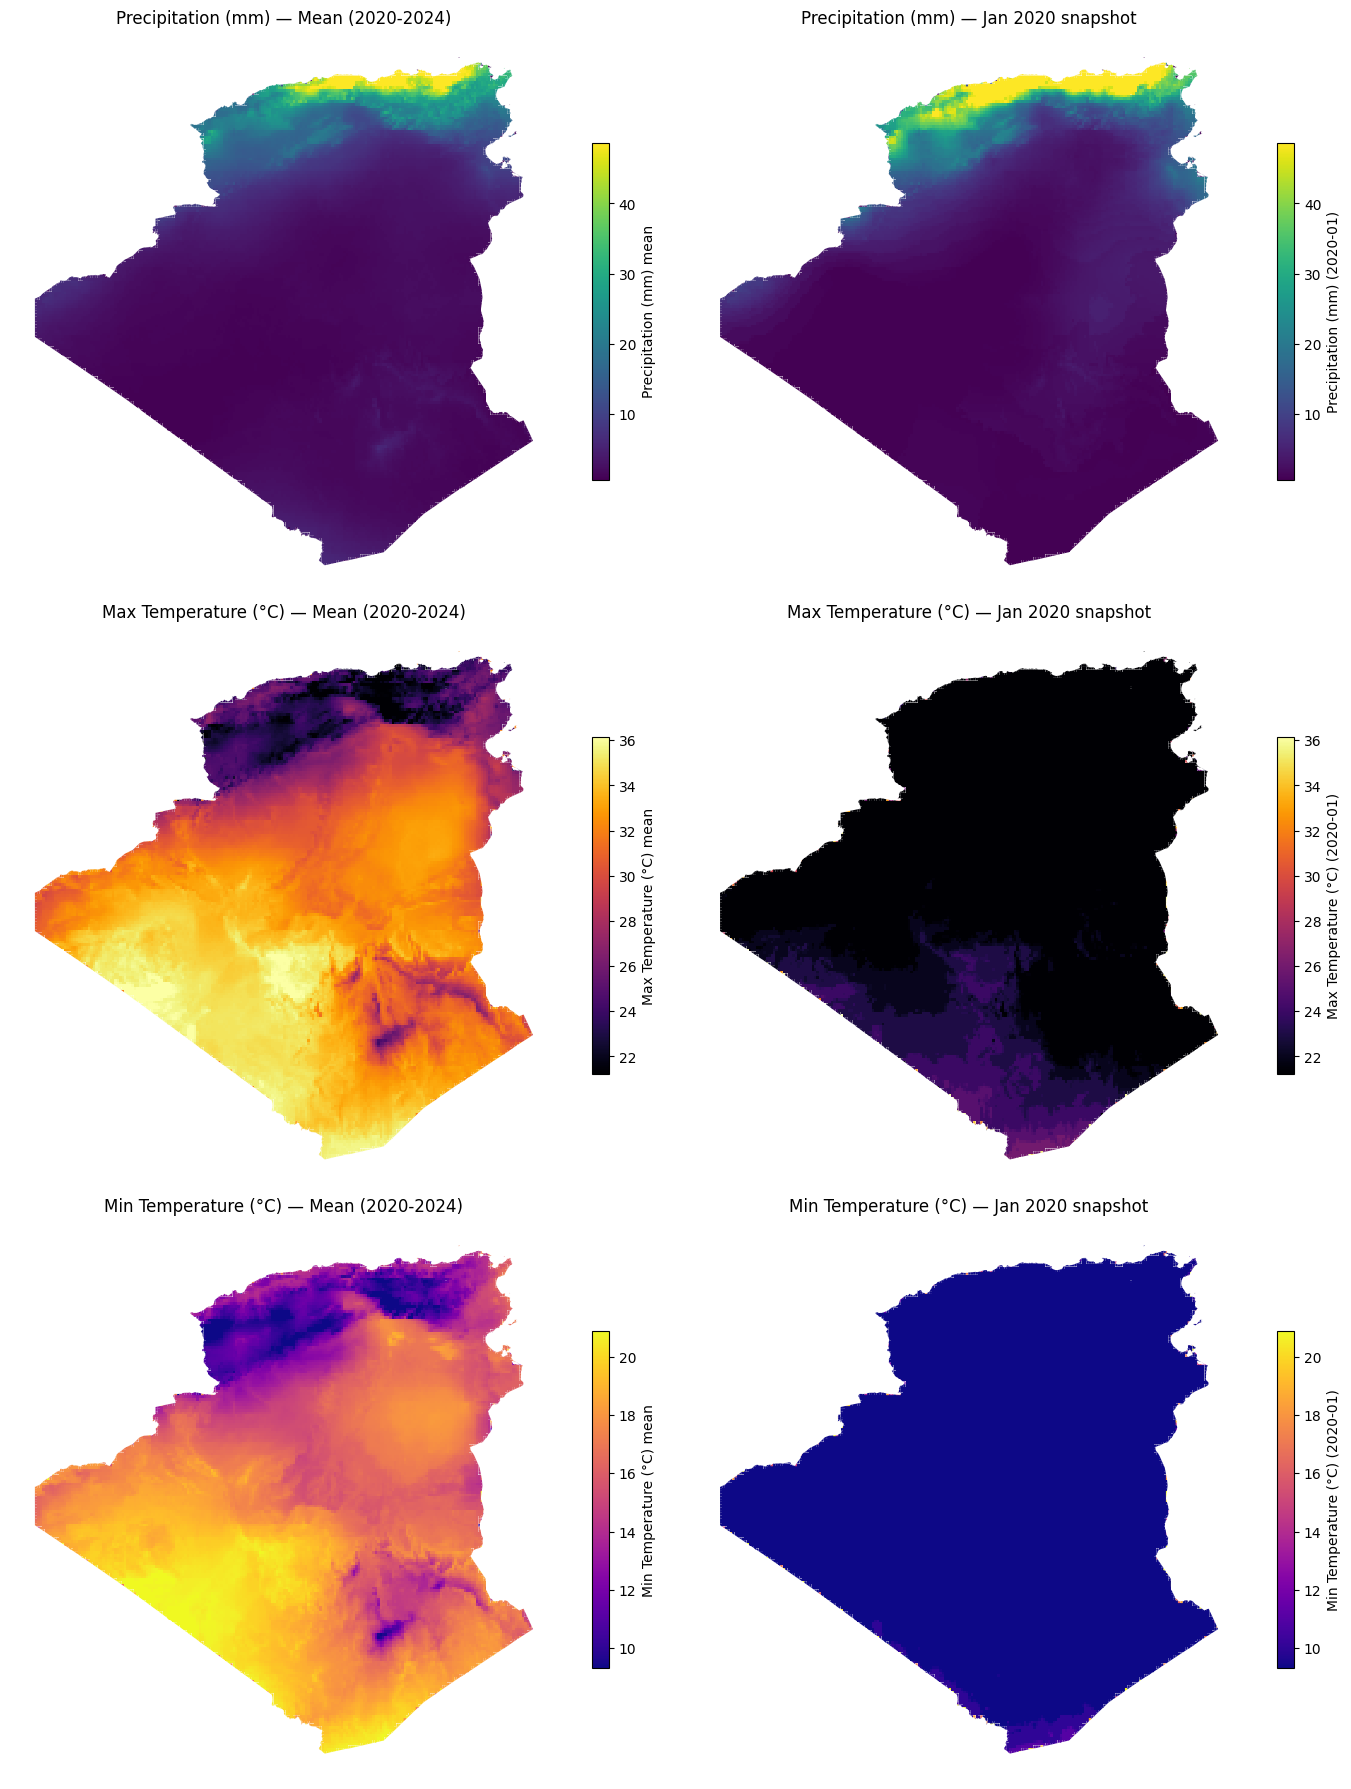

In [23]:
# Spatial heatmaps: mean across all months, and January 2020 snapshot
# Spatial heatmaps (all in one figure): mean across all months (left) and Jan 2020 snapshot (right)
vars = [
    ('prec_mm', df_prec_imputed, 'Precipitation (mm)', 'viridis'),
    ('tmax_c', df_tmax_imputed, 'Max Temperature (°C)', 'inferno'),
    ('tmin_c', df_tmin_imputed, 'Min Temperature (°C)', 'plasma'),
]

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 18))

for row, (valcol, df_im, title, cmap) in enumerate(vars):
    # aggregated mean across months (for consistent color scale per variable)
    agg_df = df_im.groupby('cell_id')[valcol].mean().reset_index()
    vmin = agg_df[valcol].quantile(0.01)
    vmax = agg_df[valcol].quantile(0.99)

    merged_mean = grid[['cell_id', 'geometry']].merge(agg_df, on='cell_id', how='left').set_geometry('geometry')
    ax_mean = axes[row, 0]
    grid.plot(ax=ax_mean, color='lightgray', edgecolor='white')
    merged_mean.plot(column=valcol, ax=ax_mean, cmap=cmap, vmin=vmin, vmax=vmax,
                     legend=True, legend_kwds={'shrink': 0.6, 'label': f"{title} mean"},
                     missing_kwds={'color': 'lightgray', 'edgecolor': 'white', 'linewidth': 0.2})
    ax_mean.set_title(f"{title} — Mean (2020-2024)")
    ax_mean.set_axis_off()

    # snapshot: January 2020
    snap_df = df_im[(df_im['year'] == 2020) & (df_im['month'] == 1)][['cell_id', valcol]]
    merged_snap = grid[['cell_id', 'geometry']].merge(snap_df, on='cell_id', how='left').set_geometry('geometry')
    ax_snap = axes[row, 1]
    grid.plot(ax=ax_snap, color='lightgray', edgecolor='white')
    merged_snap.plot(column=valcol, ax=ax_snap, cmap=cmap, vmin=vmin, vmax=vmax,
                     legend=True, legend_kwds={'shrink': 0.6, 'label': f"{title} (2020-01)"},
                     missing_kwds={'color': 'lightgray', 'edgecolor': 'white', 'linewidth': 0.2})
    ax_snap.set_title(f"{title} — Jan 2020 snapshot")
    ax_snap.set_axis_off()

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'spatial_heatmaps_all_variables.png'), dpi=300, bbox_inches='tight')
plt.show()

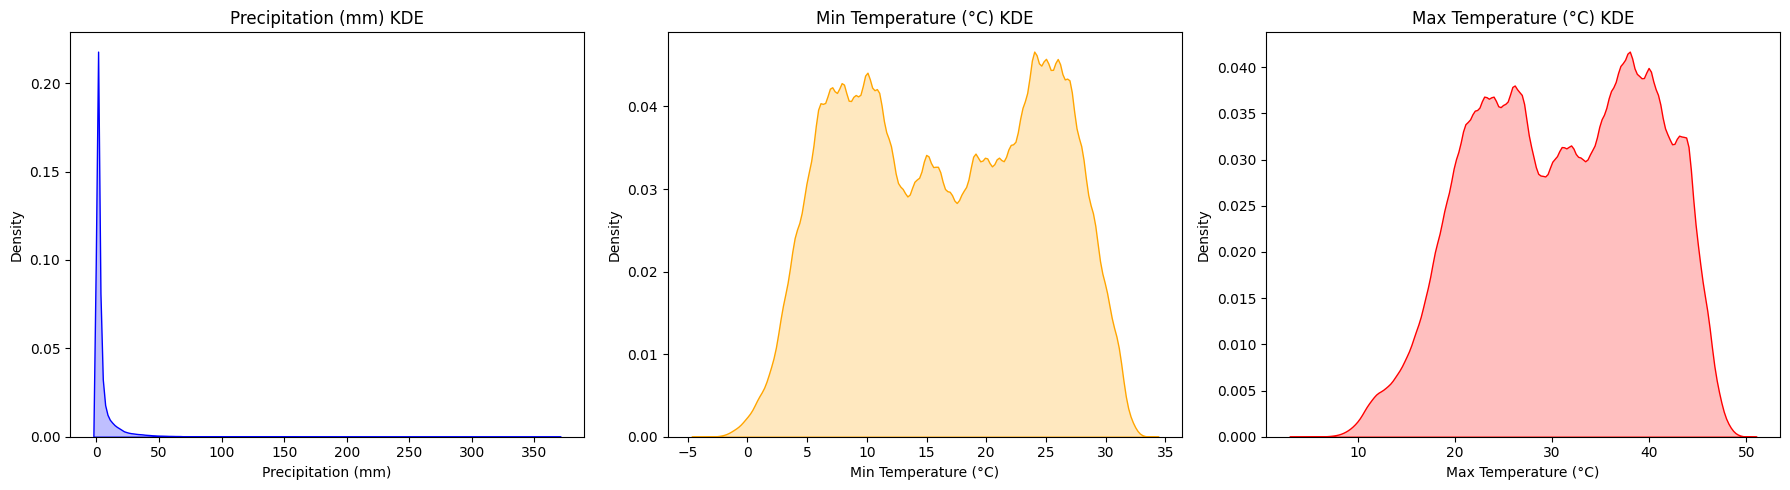

In [24]:
# plot 3 subplots kde of each on of prec tmin tmax
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
sns.kdeplot(df_prec_imputed['prec_mm'], fill=True, color='blue')
plt.title('Precipitation (mm) KDE')
plt.xlabel('Precipitation (mm)')
plt.ylabel('Density')

plt.subplot(1, 3, 2)
sns.kdeplot(df_tmin_imputed['tmin_c'], fill=True, color='orange')
plt.title('Min Temperature (°C) KDE')
plt.xlabel('Min Temperature (°C)')
plt.ylabel('Density')

plt.subplot(1, 3, 3)
sns.kdeplot(df_tmax_imputed['tmax_c'], fill=True, color='red')
plt.title('Max Temperature (°C) KDE')
plt.xlabel('Max Temperature (°C)')
plt.ylabel('Density')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'climate_kde_imputed.png'), dpi=300, bbox_inches='tight')
plt.show()

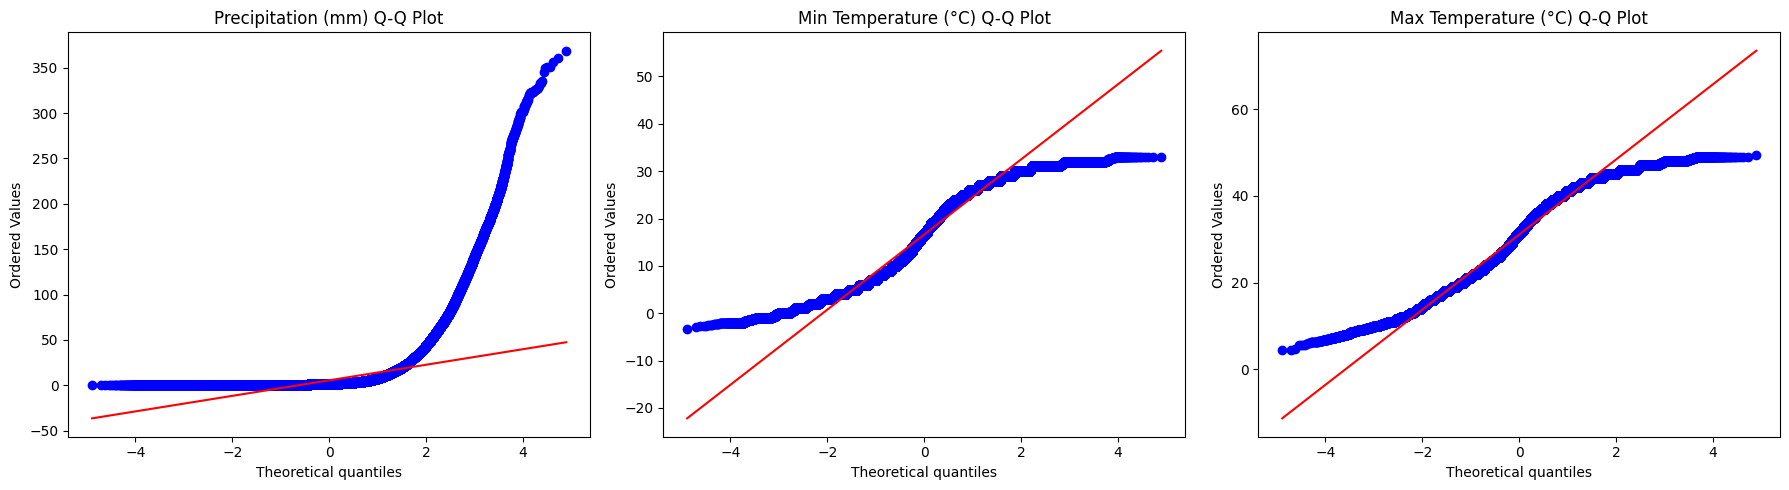

In [25]:
# Q-Q plot for each variable
from scipy import stats
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
stats.probplot(df_prec_imputed['prec_mm'], dist="norm", plot=plt)
plt.title('Precipitation (mm) Q-Q Plot')

plt.subplot(1, 3, 2)
stats.probplot(df_tmin_imputed['tmin_c'], dist="norm", plot=plt)
plt.title('Min Temperature (°C) Q-Q Plot')

plt.subplot(1, 3, 3)
stats.probplot(df_tmax_imputed['tmax_c'], dist="norm", plot=plt)
plt.title('Max Temperature (°C) Q-Q Plot')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'climate_qq_plots_imputed.png'), dpi=300, bbox_inches='tight')
plt.show()

In [26]:
df_climate_final_prec = df_prec_imputed[['cell_id', 'year', 'month', 'prec_mm']]
df_climate_final_tmax = df_tmax_imputed[['cell_id', 'year', 'month', 'tmax_c']]
df_climate_final_tmin = df_tmin_imputed[['cell_id', 'year', 'month', 'tmin_c']]

In [27]:
df_climate_merged = df_climate_final_prec.merge(
    df_climate_final_tmax,
    on=['cell_id', 'year', 'month'],
    suffixes=('_prec', '_tmax')
).merge(
    df_climate_final_tmin,
    on=['cell_id', 'year', 'month'],
    suffixes=('_tmax', '_tmin')
)

In [28]:
df_climate_merged.columns

Index(['cell_id', 'year', 'month', 'prec_mm', 'tmax_c', 'tmin_c'], dtype='object')

In [29]:
# # adding columns 
# # tmin_1_2020, tmax_1_2020, prec_1_2020 for season winter year 2020
# # tmin_2_2020, tmax_2_2020, prec_2_2020 for season spring year 2020
# # tmin_3_2020, tmax_3_2020, prec_3_2020 for season summer year 2020
# # tmin_4_2020, tmax_4_2020, prec_4_2020 for season autumn year 2020
# # tmin_1_2021, tmax_1_2021, prec_1_2021 for season winter year 2021
# # tmin_2_2021, tmax_2_2021, prec_2_2021 for season spring year 2021
# # tmin_3_2021, tmax_3_2021, prec_3_2021 for season summer year 2021
# # tmin_4_2021, tmax_4_2021, prec_4_2021 for season autumn year 2021
# # ...

# def add_seasonal_columns(df, year):
#     seasons = {
#         1: [12, 1, 2],   # Winter
#         2: [3, 4, 5],    # Spring
#         3: [6, 7, 8],    # Summer
#         4: [9, 10, 11]   # Autumn
#     }
    
#     for season_num, months in seasons.items():
#         season_df = df[(df['year'] == year) & (df['month'].isin(months))]
#         agg_df = season_df.groupby('cell_id').agg({
#             'tmin_c': 'mean',
#             'tmax_c': 'mean',
#             'prec_mm': 'sum'
#         }).reset_index()
        
#         # Rename columns before merging to avoid conflicts
#         agg_df.rename(columns={
#             'tmin_c': f'tmin_{season_num}_{year}',
#             'tmax_c': f'tmax_{season_num}_{year}',
#             'prec_mm': f'prec_{season_num}_{year}'
#         }, inplace=True)
        
#         df = df.merge(
#             agg_df,
#             on='cell_id',
#             how='left'
#         )
    
#     return df


In [30]:
# df_climate_reduced = df_climate_merged.copy()
# for yr in range(2020, 2024 + 1):
#     df_climate_reduced = add_seasonal_columns(df_climate_reduced, yr)

In [46]:
#only 2024
df_climate_2024 = df_climate_merged[df_climate_merged['year'] == 2024].copy()
#drop column year
df_climate_2024 = df_climate_2024.drop(columns=['year'])

In [ ]:
# Create 12 columns (one per month), each containing [tmin, tmax, prec] as a list
# Group by cell_id and month, then create the list format
df_climate_2024_grouped = df_climate_2024.groupby(['cell_id', 'month']).agg({
    'tmin_c': 'first',
    'tmax_c': 'first',
    'prec_mm': 'first'
}).reset_index()

# Create a list column combining all three values
df_climate_2024_grouped['climate_data'] = df_climate_2024_grouped.apply(
    lambda row: [row['tmin_c'], row['tmax_c'], row['prec_mm']], axis=1
)

# Pivot to create month columns with lists
df_climate_2024 = df_climate_2024_grouped.pivot(
    index='cell_id', 
    columns='month', 
    values='climate_data'
).reset_index()

# Rename columns to month_1, month_2, etc.
df_climate_2024.columns = ['cell_id'] + [f'month_{int(col)}' for col in df_climate_2024.columns[1:]]

print(f"Pivoted climate data shape: {df_climate_2024.shape}")
print(f"Columns: {df_climate_2024.columns.tolist()}")
print(f"\nEach month column contains: [tmin, tmax, prec]")
print(f"\nSample data:")
print(df_climate_2024.head())
print(f"\nExample - month_1 values for first row:")
print(df_climate_2024.iloc[0]['month_1'])


Pivoted climate data shape: (23322, 13)
Columns: ['cell_id', 'month_1', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9', 'month_10', 'month_11', 'month_12']

Each month column contains: [tmin, tmax, prec]

Sample data:
   cell_id                         month_1                            month_2  \
0        0                [8.5, 22.0, 2.0]                  [11.0, 25.0, 0.5]   
1        1                [8.0, 22.0, 2.0]   [11.0, 25.0, 0.4250000119209289]   
2        2  [8.5, 22.0, 2.900000095367432]  [11.0, 24.75, 0.5750000476837158]   
3        3  [8.0, 22.0, 2.825000047683716]  [10.75, 24.0, 0.5249999761581421]   
4        4  [8.0, 22.0, 2.799999952316284]                  [10.0, 24.0, 0.5]   

                            month_3                           month_4  \
0  [13.0, 27.0, 0.5750000476837158]   [18.0, 32.0, 1.475000023841858]   
1                 [13.0, 27.0, 0.5]                 [18.0, 32.0, 1.5]   
2                 [13.0, 27.0, 0.5] 

In [48]:
# Verify the structure
print("Final climate 2024 structure:")
print(df_climate_2024.info())
print(f"\nSample data:")
df_climate_2024.head()

Final climate 2024 structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23322 entries, 0 to 23321
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   cell_id   23322 non-null  int64 
 1   month_1   23322 non-null  object
 2   month_2   23322 non-null  object
 3   month_3   23322 non-null  object
 4   month_4   23322 non-null  object
 5   month_5   23322 non-null  object
 6   month_6   23322 non-null  object
 7   month_7   23322 non-null  object
 8   month_8   23322 non-null  object
 9   month_9   23322 non-null  object
 10  month_10  23322 non-null  object
 11  month_11  23322 non-null  object
 12  month_12  23322 non-null  object
dtypes: int64(1), object(12)
memory usage: 2.3+ MB
None

Sample data:


,cell_id,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
0,0,"[8.5, 22.0, 2.0]","[11.0, 25.0, 0.5]","[13.0, 27.0, 0.5750000476837158]","[18.0, 32.0, 1.475000023841858]","[20.0, 33.75, 0.0]","[23.0, 36.75, 0.0]","[27.75, 42.0, 1.2999999523162842]","[27.0, 41.0, 2.0999999046325684]","[23.0, 36.0, 52.09999847412109]","[18.0, 31.0, 7.625]","[14.0, 27.0, 6.125]","[8.0, 22.0, 4.099999904632568]"
1,1,"[8.0, 22.0, 2.0]","[11.0, 25.0, 0.4250000119209289]","[13.0, 27.0, 0.5]","[18.0, 32.0, 1.5]","[19.25, 33.25, 0.0]","[22.75, 36.25, 0.0]","[27.0, 41.75, 1.2999999523162842]","[27.0, 41.0, 2.0999999046325684]","[23.0, 36.0, 51.900001525878906]","[18.0, 31.0, 7.149999618530273]","[14.0, 27.0, 6.199999809265137]","[8.0, 21.75, 4.099999904632568]"
2,2,"[8.5, 22.0, 2.900000095367432]","[11.0, 24.75, 0.5750000476837158]","[13.0, 27.0, 0.5]","[17.5, 31.5, 1.5]","[19.0, 33.0, 0.0]","[22.0, 36.0, 0.0]","[27.0, 41.5, 1.2999999523162842]","[27.0, 41.0, 2.200000047683716]","[22.75, 36.0, 52.45000076293945]","[18.0, 31.0, 8.125]","[13.5, 27.0, 6.449999809265137]","[8.0, 21.25, 5.300000190734863]"
3,3,"[8.0, 22.0, 2.825000047683716]","[10.75, 24.0, 0.5249999761581421]","[13.0, 27.0, 0.449999988079071]","[17.0, 31.0, 1.4500000476837158]","[19.0, 33.0, 0.0]","[22.0, 36.0, 0.0]","[27.0, 41.0, 1.2999999523162842]","[26.75, 41.0, 2.200000047683716]","[22.0, 36.0, 52.75]","[18.0, 31.0, 8.100000381469727]","[13.0, 27.0, 7.325000286102295]","[8.0, 21.0, 5.625]"
4,4,"[8.0, 22.0, 2.799999952316284]","[10.0, 24.0, 0.5]","[12.5, 27.0, 0.4000000059604645]","[17.0, 31.0, 1.774999976158142]","[19.0, 33.0, 0.0]","[22.0, 36.0, 0.0]","[27.0, 41.0, 1.2999999523162842]","[26.25, 41.0, 2.200000047683716]","[22.0, 36.0, 53.025001525878906]","[18.0, 31.0, 8.100000381469727]","[13.0, 26.0, 7.300000190734863]","[8.0, 21.0, 6.5]"


In [49]:
# Check for any missing values in the pivoted data
print("Missing values per column:")
missing_counts = df_climate_2024.isna().sum()
if missing_counts.sum() > 0:
    print(missing_counts[missing_counts > 0])
else:
    print("No missing values!")
print(f"\nTotal missing values: {df_climate_2024.isna().sum().sum()}")

Missing values per column:
No missing values!

Total missing values: 0


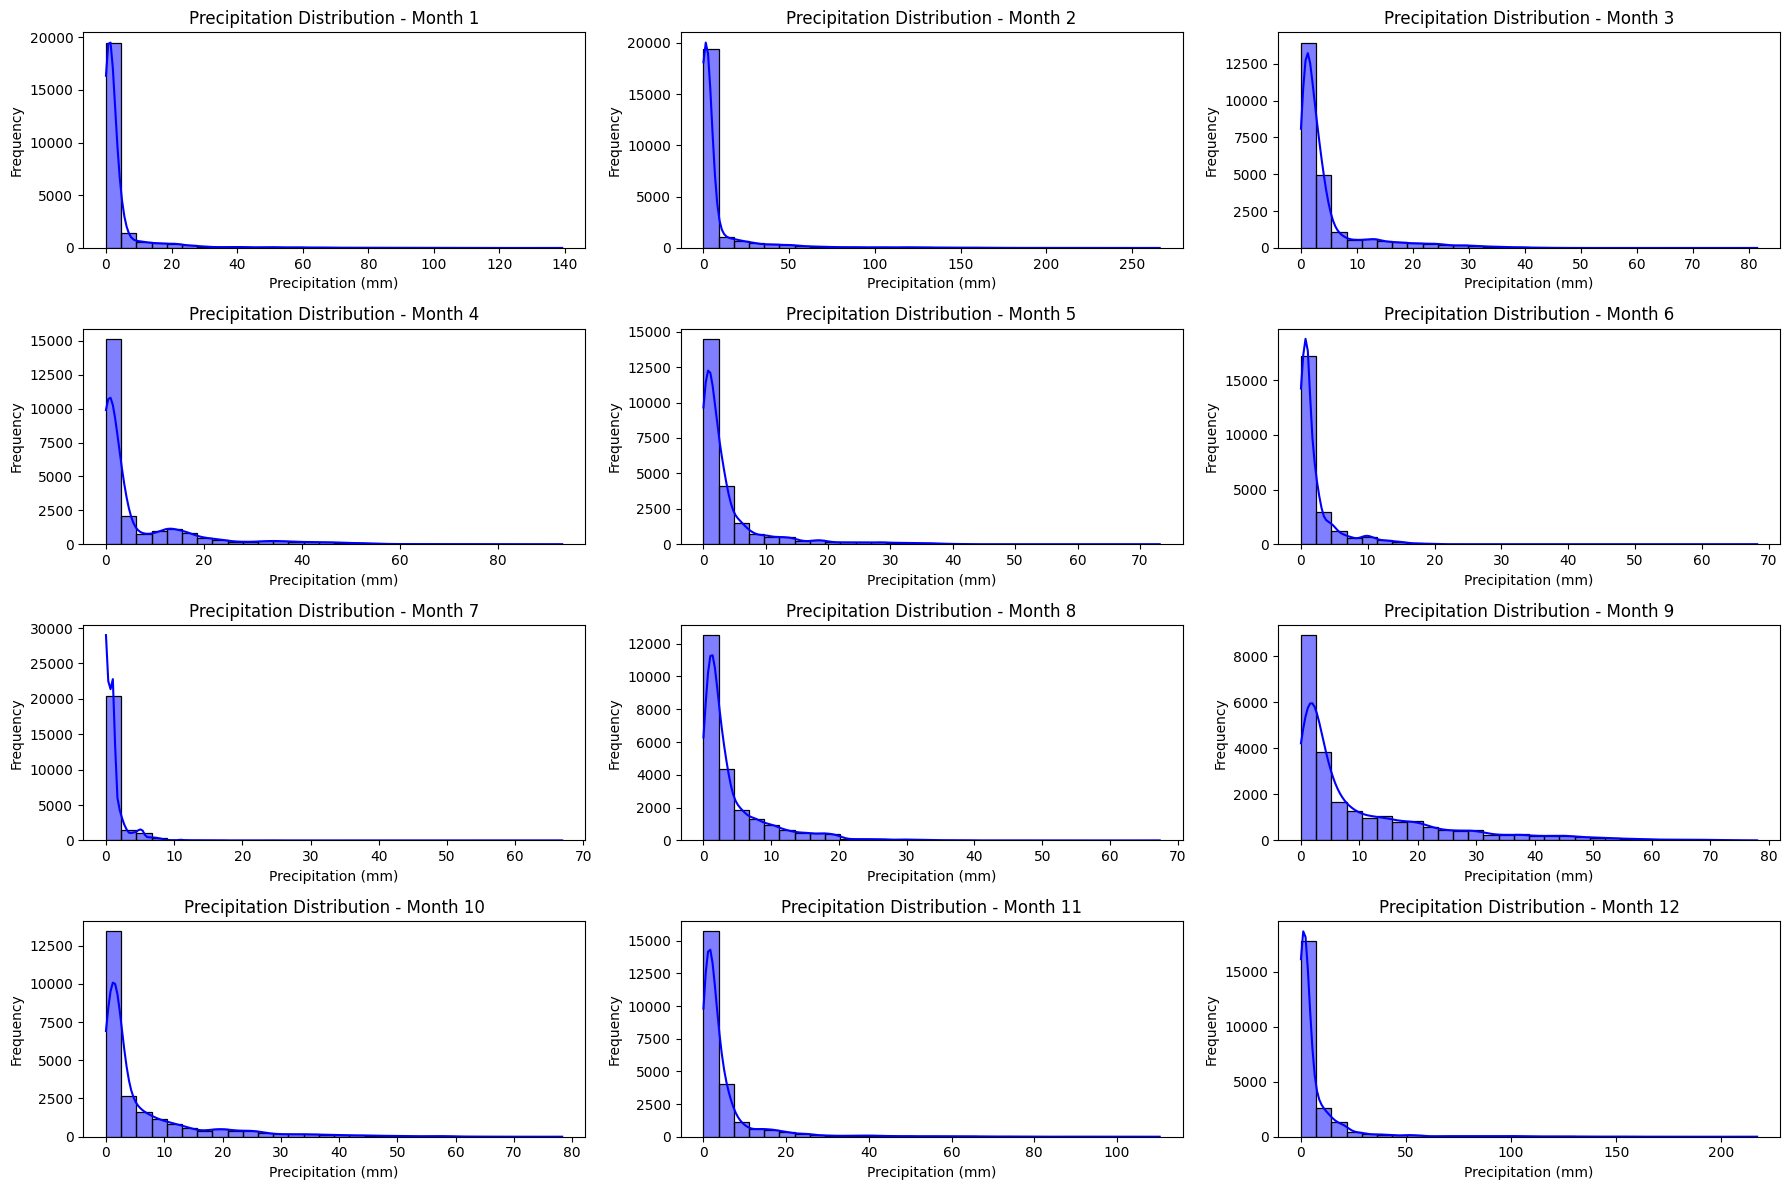

In [50]:
# Plot the distribution of precipitation for each month
plt.figure(figsize=(18, 12))
for month in range(1, 13):
    plt.subplot(4, 3, month)
    month_data = df_climate_2024[f'month_{month}'].dropna().apply(lambda x: x[2])  # extract prec
    sns.histplot(month_data, bins=30, kde=True, color='blue')
    plt.title(f'Precipitation Distribution - Month {month}')
    plt.xlabel('Precipitation (mm)')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'precipitation_monthly_distribution_2024.png'), dpi=300, bbox_inches='tight')
plt.show()

In [51]:
# Verify the structure
print("Final climate 2024 structure:")
print(df_climate_2024.info())
print(f"\nSample data:")
df_climate_2024.head()


Final climate 2024 structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23322 entries, 0 to 23321
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   cell_id   23322 non-null  int64 
 1   month_1   23322 non-null  object
 2   month_2   23322 non-null  object
 3   month_3   23322 non-null  object
 4   month_4   23322 non-null  object
 5   month_5   23322 non-null  object
 6   month_6   23322 non-null  object
 7   month_7   23322 non-null  object
 8   month_8   23322 non-null  object
 9   month_9   23322 non-null  object
 10  month_10  23322 non-null  object
 11  month_11  23322 non-null  object
 12  month_12  23322 non-null  object
dtypes: int64(1), object(12)
memory usage: 2.3+ MB
None

Sample data:


,cell_id,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
0,0,"[8.5, 22.0, 2.0]","[11.0, 25.0, 0.5]","[13.0, 27.0, 0.5750000476837158]","[18.0, 32.0, 1.475000023841858]","[20.0, 33.75, 0.0]","[23.0, 36.75, 0.0]","[27.75, 42.0, 1.2999999523162842]","[27.0, 41.0, 2.0999999046325684]","[23.0, 36.0, 52.09999847412109]","[18.0, 31.0, 7.625]","[14.0, 27.0, 6.125]","[8.0, 22.0, 4.099999904632568]"
1,1,"[8.0, 22.0, 2.0]","[11.0, 25.0, 0.4250000119209289]","[13.0, 27.0, 0.5]","[18.0, 32.0, 1.5]","[19.25, 33.25, 0.0]","[22.75, 36.25, 0.0]","[27.0, 41.75, 1.2999999523162842]","[27.0, 41.0, 2.0999999046325684]","[23.0, 36.0, 51.900001525878906]","[18.0, 31.0, 7.149999618530273]","[14.0, 27.0, 6.199999809265137]","[8.0, 21.75, 4.099999904632568]"
2,2,"[8.5, 22.0, 2.900000095367432]","[11.0, 24.75, 0.5750000476837158]","[13.0, 27.0, 0.5]","[17.5, 31.5, 1.5]","[19.0, 33.0, 0.0]","[22.0, 36.0, 0.0]","[27.0, 41.5, 1.2999999523162842]","[27.0, 41.0, 2.200000047683716]","[22.75, 36.0, 52.45000076293945]","[18.0, 31.0, 8.125]","[13.5, 27.0, 6.449999809265137]","[8.0, 21.25, 5.300000190734863]"
3,3,"[8.0, 22.0, 2.825000047683716]","[10.75, 24.0, 0.5249999761581421]","[13.0, 27.0, 0.449999988079071]","[17.0, 31.0, 1.4500000476837158]","[19.0, 33.0, 0.0]","[22.0, 36.0, 0.0]","[27.0, 41.0, 1.2999999523162842]","[26.75, 41.0, 2.200000047683716]","[22.0, 36.0, 52.75]","[18.0, 31.0, 8.100000381469727]","[13.0, 27.0, 7.325000286102295]","[8.0, 21.0, 5.625]"
4,4,"[8.0, 22.0, 2.799999952316284]","[10.0, 24.0, 0.5]","[12.5, 27.0, 0.4000000059604645]","[17.0, 31.0, 1.774999976158142]","[19.0, 33.0, 0.0]","[22.0, 36.0, 0.0]","[27.0, 41.0, 1.2999999523162842]","[26.25, 41.0, 2.200000047683716]","[22.0, 36.0, 53.025001525878906]","[18.0, 31.0, 8.100000381469727]","[13.0, 26.0, 7.300000190734863]","[8.0, 21.0, 6.5]"


In [52]:
# Save merged climate data to CSV
output_folder = '../../Cleaned_Data/'
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# Save merged climate data to CSV
output_path = os.path.join(output_folder, 'climate_2024_imputed.csv')
df_climate_2024.to_csv(output_path, index=False)
print(f"\nMerged climate data saved to: {output_path}")


Merged climate data saved to: ../../Cleaned_Data/climate_2024_imputed.csv
